In [62]:
import numpy  as np
import pandas as pd

In [63]:
import tensorflow
import keras 
from keras.datasets import mnist

In [64]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [65]:
from keras.layers import Dense,Conv2D
from keras import Sequential

In [66]:
X_train.shape

(60000, 28, 28)

In [67]:
import matplotlib.pyplot as plt

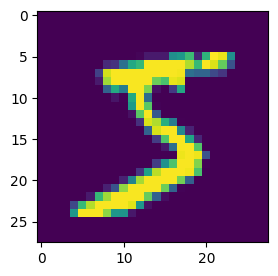

In [68]:
plt.figure(figsize=(3,3))
plt.imshow(X_train[0])

## Applying CNN

In [69]:
from keras.layers import MaxPooling2D,Flatten

In [70]:
model = Sequential()

In [71]:
model.add(Conv2D(30,kernel_size=(3,3),padding="valid",strides=(1,1),activation="relu",input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2),padding="valid"))
model.add(Conv2D(30,kernel_size=(3,3),padding="valid",strides=(1,1),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2),padding="valid"))
model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dense(10,activation="softmax"))          

In [72]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 26, 26, 30)          │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 13, 13, 30)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 11, 11, 30)          │           8,130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 5, 5, 30)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 750)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          96,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 105,848 (413.47 KB)

 Trainable params: 105,848 (413.47 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [74]:
hist = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=2,batch_size=32)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8808 - loss: 1.0312 - val_accuracy: 0.9714 - val_loss: 0.0876
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9809 - loss: 0.0650 - val_accuracy: 0.9781 - val_loss: 0.0739


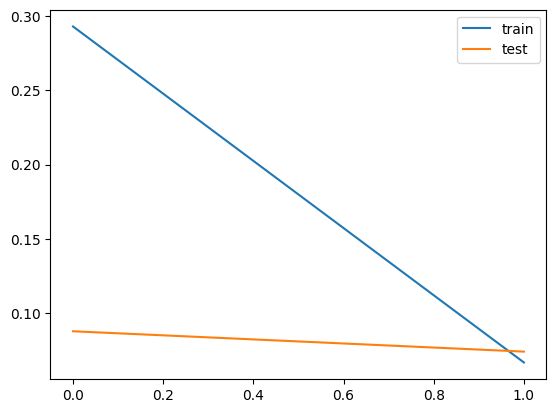

In [75]:
plt.plot(hist.history['loss'],label="train")
plt.plot(hist.history['val_loss'],label="test")
plt.legend()
plt.show()

In [76]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [83]:
pred= model.predict(np.expand_dims(X_test[0], axis=0))
prediction = np.argmax(pred)
print("pred:", prediction)
print("actual:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
pred: 7
actual: 7
